**Aufgabe 4**

In dieser Aufgabe wird das "keras" API verwendet, um ein neuronales Netz (NN) wie in der Aufgabe 3 zu schreiben. Leider ist die Implementierung eines NN mit derselben Topologie kompliziert, aus diesem Grund schreiben wir einfaches NN mit der Struktur: 4 Inputsneuronen -> 1 Outputsneuron. Diese ist erreichbar mit dem Sequential-Model ohne Hidden-Layers. Als am häufigsten verwendete Loss-Funktion, Optimizer und Metrics setzen wir binäre Kreuzentropie, Gradientenabstieg und Genauigkeit.

Anzahl Trainingsmuster: 16
Anteil positiver Muster (Schachbrett): 12.50%


C:\Users\toima\PycharmProjects\Neuronensimulation\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)


Test-Loss:        0.4595
Test-Genauigkeit: 81.25%

Muster | Vorhersage | Rundung | tatsaechliches Label
[0 0 0 0] | 0.4555    | 0       | 0
[0 0 0 1] | 0.5105    | 1       | 0
[0 0 1 0] | 0.2776    | 0       | 0
[0 0 1 1] | 0.3239    | 0       | 0
[0 1 0 0] | 0.3154    | 0       | 0
[0 1 0 1] | 0.3649    | 0       | 0
[0 1 1 0] | 0.1747    | 0       | 1
[0 1 1 1] | 0.2088    | 0       | 0
[1 0 0 0] | 0.2973    | 0       | 0
[1 0 0 1] | 0.3453    | 0       | 1
[1 0 1 0] | 0.1627    | 0       | 0
[1 0 1 1] | 0.1950    | 0       | 0
[1 1 0 0] | 0.1890    | 0       | 0
[1 1 0 1] | 0.2251    | 0       | 0
[1 1 1 0] | 0.0967    | 0       | 0
[1 1 1 1] | 0.1177    | 0       | 0

13/16 Muster korrekt klassifiziert.


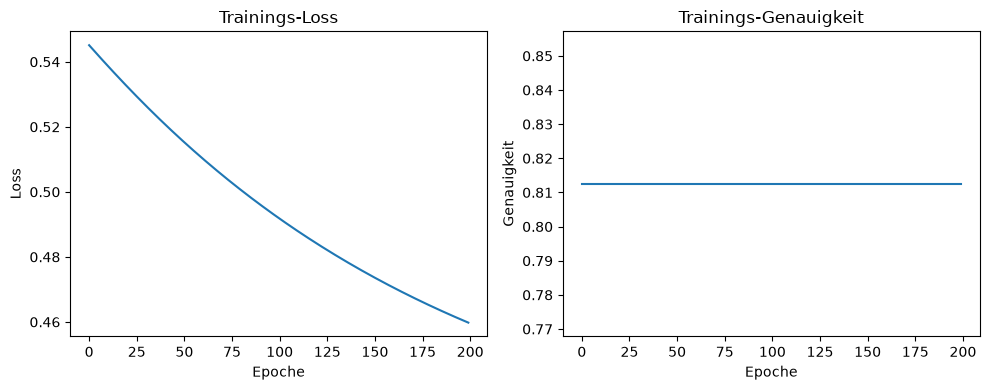

In [1]:
import keras
from keras import layers
import aufgabe3.set_of_boards
from aufgabe3 import set_of_boards

"""
Aufgabe 4: Einfuehrung in Keras - Schachbretterkennung
========================================================
Loest das Schachbrett-Klassifikationsproblem aus Aufgabe 3 nun mit Keras,
statt mit dem selbstgeschriebenen Hodgkin-Huxley-basierten Netz.
"""

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# ---------------------------------------------------------------------------
# 4a) Datenpraeparation
# ---------------------------------------------------------------------------
# Feature: alle 16 moeglichen 2x2-Muster, Shape (16, 2, 2)
X = set_of_boards.get_set_of_boards().astype("float32")
# Target: 1, wenn Schachbrettmuster (Diagonalen gleichfarbig), sonst 0
y = set_of_boards.get_targets().astype("float32")

# Da es nur 16 Kombinationen gibt, koennen wir laut Aufgabenstellung
# alle Muster sowohl fuer Training als auch fuer den Test verwenden.
x_train, y_train = X, y
x_test, y_test = X, y

print(f"Anzahl Trainingsmuster: {len(x_train)}")
print(f"Anteil positiver Muster (Schachbrett): {y_train.mean():.2%}")


# ---------------------------------------------------------------------------
# 4b) Modellaufbau
# ---------------------------------------------------------------------------
# Analog zu Aufgabe 3: 4 Input-Neuronen (die 4 Felder) + 1 Output-Neuron,
# insgesamt 5 Neuronen, KEIN Hidden Layer.
# Flatten() macht aus dem 2x2-Board einen 4-elementigen Vektor.
# Sigmoid als Output-Aktivierung, da wir eine binaere Klassifikation
# (Schachbrett ja/nein, Wert zwischen 0 und 1) vorhersagen wollen.
model = Sequential()
model.add(Flatten(input_shape=(2, 2)))
model.add(Dense(1, activation="sigmoid"))  # Output-Layer

model.summary()


# ---------------------------------------------------------------------------
# 4c) Kompilierung
# ---------------------------------------------------------------------------
# binary_crossentropy ist die Standard-Loss-Funktion fuer binaere
# Klassifikationsprobleme mit Sigmoid-Output.
# adam ist ein robuster, adaptiver Optimizer, gut geeignet als Standardwahl.
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)


# ---------------------------------------------------------------------------
# 4d) Training und Evaluation
# ---------------------------------------------------------------------------
history = model.fit(
    x_train, y_train,
    epochs=200,
    verbose=0,
)

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest-Loss:        {loss:.4f}")
print(f"Test-Genauigkeit: {accuracy:.2%}")

predictions = model.predict(x_test, verbose=0).flatten()
print("\nMuster | Vorhersage | Rundung | tatsaechliches Label")
for board, pred, target in zip(x_test, predictions, y_test):
    print(f"{board.flatten().astype(int)} | {pred:.4f}    | {round(pred)}       | {int(target)}")

korrekt = np.sum(np.round(predictions) == y_test)
print(f"\n{korrekt}/{len(y_test)} Muster korrekt klassifiziert.")


# ---------------------------------------------------------------------------
# Trainingsverlauf visualisieren (Loss & Accuracy ueber die Epochen)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history["loss"])
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Loss")
axes[0].set_title("Trainings-Loss")

axes[1].plot(history.history["accuracy"])
axes[1].set_xlabel("Epoche")
axes[1].set_ylabel("Genauigkeit")
axes[1].set_title("Trainings-Genauigkeit")

plt.tight_layout()
plt.show()